# Customer Profile Analysis

**Project:** StudyBuild online-store customer analysis  
**Phase:** Phase 2 - exploratory customer analysis  
**Input:** `data/cleaned_dataset_FatemehDehghan224.xlsx`

This notebook starts the second phase of the project. It uses the cleaned customer dataset from Phase 1 and answers the first business question through a focused exploratory analysis. Each question should remain in its own section so future questions can be added without mixing code, charts, or conclusions.

## 0. Environment and Project Paths

This setup section imports the required libraries, uses a non-interactive Matplotlib backend when the notebook is executed as a script, and locates the project root from either the repository root or the `analysis_code/` folder. The analysis only reads the cleaned dataset produced by the cleaning pipeline.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib

try:
    from IPython import get_ipython
except ImportError:
    get_ipython = lambda: None

if get_ipython() is None:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    def display(value: object) -> None:
        """Print a value when IPython display is unavailable."""
        print(value)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


def find_project_root(start: Path) -> Path:
    """Return the nearest parent directory that contains the cleaned dataset."""
    start = start.resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        cleaned_path = candidate / "data" / "cleaned_dataset_FatemehDehghan224.xlsx"
        if cleaned_path.exists():
            return candidate
    raise FileNotFoundError(
        "Could not find data/cleaned_dataset_FatemehDehghan224.xlsx from the current path."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data"
CLEANED_DATA_PATH = DATA_DIR / "cleaned_dataset_FatemehDehghan224.xlsx"

REQUIRED_COLUMNS = [
    "customer_id",
    "gender",
    "age",
    "membership_tier",
    "device",
    "payment_method",
]

PROJECT_ROOT, CLEANED_DATA_PATH

(WindowsPath('F:/Data Analysis/project-01-data-cleaning-FatemehDehghan224/studybuild-data-cleaning-01/submissions/FatemehDehghan224'),
 WindowsPath('F:/Data Analysis/project-01-data-cleaning-FatemehDehghan224/studybuild-data-cleaning-01/submissions/FatemehDehghan224/data/cleaned_dataset_FatemehDehghan224.xlsx'))

## Question 1 - Main Customer Profile

**Business question:** Who are the store's main customers?

Before designing an advertising campaign, management needs a clear picture of current customers. This section analyzes the requested customer characteristics: `gender`, `age`, `membership_tier`, `device`, and `payment_method`.

The expected outputs are:

- A concise summary table of the dominant customer characteristics.
- Bar charts for age groups, membership tiers, devices, and payment methods.
- A final paragraph that describes the main customer profile based only on the cleaned data.

### 1. Load and Validate the Cleaned Dataset

The analysis starts from the cleaned Excel workbook exported by Phase 1. The code checks that all columns required for this question are available before any chart or summary is created.

In [2]:
def load_cleaned_customer_data(path: Path) -> pd.DataFrame:
    """Load the cleaned customer workbook and validate the question-specific columns.

    Args:
        path: Path to the cleaned Excel workbook produced by the cleaning phase.

    Returns:
        A pandas DataFrame containing the cleaned customer records.

    Raises:
        FileNotFoundError: If the cleaned workbook does not exist.
        ValueError: If one or more required analysis columns are missing.
    """
    if not path.exists():
        raise FileNotFoundError(f"Cleaned dataset was not found: {path}")

    df = pd.read_excel(path, sheet_name="customers")
    missing_columns = sorted(set(REQUIRED_COLUMNS) - set(df.columns))
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")
    return df


customer_df = load_cleaned_customer_data(CLEANED_DATA_PATH)

load_summary = pd.DataFrame(
    {
        "metric": ["rows", "columns", "unique_customers", "duplicate_customer_ids"],
        "value": [
            len(customer_df),
            customer_df.shape[1],
            customer_df["customer_id"].nunique(),
            int(customer_df["customer_id"].duplicated().sum()),
        ],
    }
)
display(load_summary)

display(customer_df[REQUIRED_COLUMNS].head())

,metric,value
0,rows,60
1,columns,17
2,unique_customers,60
3,duplicate_customer_ids,0


,customer_id,gender,age,membership_tier,device,payment_method
0,1001,1,19,VIP,Android,Card
1,1002,1,53,Gold,Web,Card
2,1003,1,31,Gold,iPhone,Online Wallet
3,1004,1,58,Gold,Android,Card
4,1005,0,28,Silver,Android,Online Wallet


### 2. Prepare Analysis Columns

Only rows with complete values in the requested variables are used for this question. The cleaned dataset stores `gender` as a numeric modeling field, so this section converts it back to readable labels for reporting. Age is also converted into ordered age groups with `pd.cut()` so customers can be compared by meaningful segments.

In [3]:
GENDER_LABELS = {
    0: "Female",
    1: "Male",
    "0": "Female",
    "1": "Male",
    "F": "Female",
    "M": "Male",
    "Female": "Female",
    "Male": "Male",
}

AGE_BINS = [0, 24, 34, 44, 54, 64, float("inf")]
AGE_LABELS = ["Under 25", "25-34", "35-44", "45-54", "55-64", "65 and older"]


def prepare_customer_profile_data(df: pd.DataFrame) -> pd.DataFrame:
    """Create a complete and readable dataset for customer profile analysis.

    Args:
        df: Cleaned customer dataset.

    Returns:
        A copy of the required profile columns with readable gender labels and age groups.
    """
    profile_df = df.dropna(subset=REQUIRED_COLUMNS).copy()
    profile_df["gender_label"] = profile_df["gender"].map(GENDER_LABELS)
    profile_df["gender_label"] = profile_df["gender_label"].fillna(profile_df["gender"].astype(str))
    profile_df["age_group"] = pd.cut(
        profile_df["age"],
        bins=AGE_BINS,
        labels=AGE_LABELS,
        include_lowest=True,
    )
    return profile_df


analysis_df = prepare_customer_profile_data(customer_df)

preparation_summary = pd.DataFrame(
    {
        "metric": ["input_rows", "rows_used_for_question_1", "rows_removed_due_to_required_missing_values"],
        "value": [len(customer_df), len(analysis_df), len(customer_df) - len(analysis_df)],
    }
)
display(preparation_summary)

display(analysis_df[["customer_id", "gender_label", "age", "age_group", "membership_tier", "device", "payment_method"]].head())

,metric,value
0,input_rows,60
1,rows_used_for_question_1,60
2,rows_removed_due_to_required_missing_values,0


,customer_id,gender_label,age,age_group,membership_tier,device,payment_method
0,1001,Male,19,Under 25,VIP,Android,Card
1,1002,Male,53,45-54,Gold,Web,Card
2,1003,Male,31,25-34,Gold,iPhone,Online Wallet
3,1004,Male,58,55-64,Gold,Android,Card
4,1005,Female,28,25-34,Silver,Android,Online Wallet


### 3. Summary Table of Customer Characteristics

This table gives a compact view of each requested feature. It includes both the customer count and the percentage share, which makes it easier to compare categories even when future datasets have a different row count.

In [4]:
def build_count_share_table(
    df: pd.DataFrame,
    column: str,
    feature_name: str,
    sort_by_count: bool = True,
) -> pd.DataFrame:
    """Build a count-and-share table for one categorical customer feature.

    Args:
        df: Prepared customer profile dataset.
        column: Column name to summarize.
        feature_name: Human-readable feature name for the output table.
        sort_by_count: Whether to sort categories by customer count in descending order.

    Returns:
        A DataFrame with category counts and percentage shares.
    """
    counts = df[column].value_counts(sort=False, dropna=False)
    if sort_by_count:
        counts = counts.sort_values(ascending=False)

    result = counts.rename_axis("category").reset_index(name="customer_count")
    result.insert(0, "feature", feature_name)
    result["share_percent"] = (result["customer_count"] / len(df) * 100).round(1)
    return result


profile_tables = [
    build_count_share_table(analysis_df, "gender_label", "Gender"),
    build_count_share_table(analysis_df, "age_group", "Age group", sort_by_count=False),
    build_count_share_table(analysis_df, "membership_tier", "Membership tier"),
    build_count_share_table(analysis_df, "device", "Device"),
    build_count_share_table(analysis_df, "payment_method", "Payment method"),
]

customer_characteristics_table = pd.concat(profile_tables, ignore_index=True)
display(customer_characteristics_table)

,feature,category,customer_count,share_percent
0,Gender,Male,35,58.3
1,Gender,Female,25,41.7
2,Age group,Under 25,7,11.7
3,Age group,25-34,11,18.3
4,Age group,35-44,10,16.7
5,Age group,45-54,15,25.0
6,Age group,55-64,16,26.7
7,Age group,65 and older,1,1.7
8,Membership tier,Gold,19,31.7
9,Membership tier,Bronze,18,30.0


In [5]:
def summarize_customer_profile(df: pd.DataFrame) -> pd.Series:
    """Calculate the dominant values needed for the final customer profile answer.

    Args:
        df: Prepared customer profile dataset.

    Returns:
        A named pandas Series containing the main profile metrics.
    """
    age_counts = df["age_group"].value_counts(sort=False)
    gender_counts = df["gender_label"].value_counts()
    membership_counts = df["membership_tier"].value_counts()
    device_counts = df["device"].value_counts()
    payment_counts = df["payment_method"].value_counts()

    return pd.Series(
        {
            "customer_count": df["customer_id"].nunique(),
            "mean_age": round(df["age"].mean(), 1),
            "median_age": round(df["age"].median(), 1),
            "dominant_age_group": age_counts.idxmax(),
            "dominant_age_group_count": int(age_counts.max()),
            "dominant_gender": gender_counts.idxmax(),
            "dominant_gender_count": int(gender_counts.max()),
            "dominant_membership_tier": membership_counts.idxmax(),
            "dominant_membership_tier_count": int(membership_counts.max()),
            "dominant_device": device_counts.idxmax(),
            "dominant_device_count": int(device_counts.max()),
            "dominant_payment_method": payment_counts.idxmax(),
            "dominant_payment_method_count": int(payment_counts.max()),
        },
        name="value",
    )


profile_summary = summarize_customer_profile(analysis_df)
display(profile_summary)

customer_count                               60
mean_age                                   43.7
median_age                                 45.0
dominant_age_group                        55-64
dominant_age_group_count                     16
dominant_gender                            Male
dominant_gender_count                        35
dominant_membership_tier                   Gold
dominant_membership_tier_count               19
dominant_device                         Android
dominant_device_count                        22
dominant_payment_method           Online Wallet
dominant_payment_method_count                23
Name: value, dtype: object

### 4. Age Group Distribution

This chart shows whether the store's customer base is concentrated in younger, middle-aged, or older adult segments. Age is grouped before plotting because campaign targeting decisions are usually made by segment rather than by exact age.

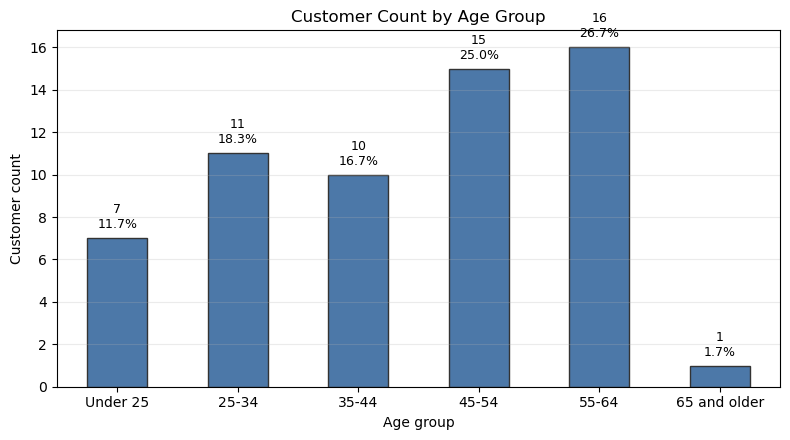

<Axes: title={'center': 'Customer Count by Age Group'}, xlabel='Age group', ylabel='Customer count'>

In [6]:
def add_bar_labels(ax: plt.Axes, total: int, orientation: str = "vertical") -> None:
    """Add count and percentage labels to a Matplotlib bar chart.

    Args:
        ax: Matplotlib axes that already contains bar patches.
        total: Total number of customers used to calculate percentages.
        orientation: Either "vertical" or "horizontal".
    """
    for patch in ax.patches:
        if orientation == "horizontal":
            count = patch.get_width()
            x = patch.get_width()
            y = patch.get_y() + patch.get_height() / 2
            ax.annotate(
                f"{int(count)} ({count / total * 100:.1f}%)",
                (x, y),
                xytext=(5, 0),
                textcoords="offset points",
                va="center",
                fontsize=9,
            )
        else:
            count = patch.get_height()
            x = patch.get_x() + patch.get_width() / 2
            y = patch.get_height()
            ax.annotate(
                f"{int(count)}\n{count / total * 100:.1f}%",
                (x, y),
                xytext=(0, 5),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9,
            )


def plot_count_chart(
    counts: pd.Series,
    title: str,
    xlabel: str,
    ylabel: str,
    color: str,
    orientation: str = "vertical",
    figsize: tuple[float, float] = (8, 4.5),
) -> plt.Axes:
    """Plot a count chart with readable labels and percentage annotations.

    Args:
        counts: Category counts to plot.
        title: Chart title.
        xlabel: X-axis label.
        ylabel: Y-axis label.
        color: Bar color.
        orientation: Either "vertical" or "horizontal".
        figsize: Figure size in inches.

    Returns:
        The Matplotlib axes object for optional downstream customization.
    """
    fig, ax = plt.subplots(figsize=figsize)
    if orientation == "horizontal":
        counts.sort_values().plot(kind="barh", ax=ax, color=color, edgecolor="#333333")
        add_bar_labels(ax, total=int(counts.sum()), orientation="horizontal")
    else:
        counts.plot(kind="bar", ax=ax, color=color, edgecolor="#333333")
        add_bar_labels(ax, total=int(counts.sum()), orientation="vertical")
        ax.tick_params(axis="x", rotation=0)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y" if orientation == "vertical" else "x", alpha=0.25)
    plt.tight_layout()
    plt.show()
    return ax


age_counts = analysis_df["age_group"].value_counts(sort=False)
plot_count_chart(
    age_counts,
    title="Customer Count by Age Group",
    xlabel="Age group",
    ylabel="Customer count",
    color="#4C78A8",
)

### 5. Gender Distribution

Gender is included because it is one of the requested customer characteristics. The cleaned dataset stores it as a binary encoded field for modeling, but the chart uses readable labels for interpretation.

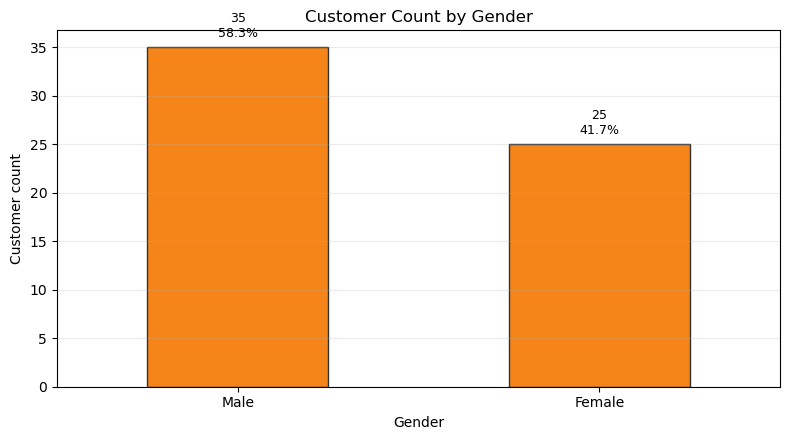

<Axes: title={'center': 'Customer Count by Gender'}, xlabel='Gender', ylabel='Customer count'>

In [7]:
gender_counts = analysis_df["gender_label"].value_counts()
plot_count_chart(
    gender_counts,
    title="Customer Count by Gender",
    xlabel="Gender",
    ylabel="Customer count",
    color="#F58518",
)

### 6. Membership Tier Distribution

This chart shows which membership tiers are most common among current customers. The result helps decide whether the campaign should focus on loyalty growth, retention, or reactivation.

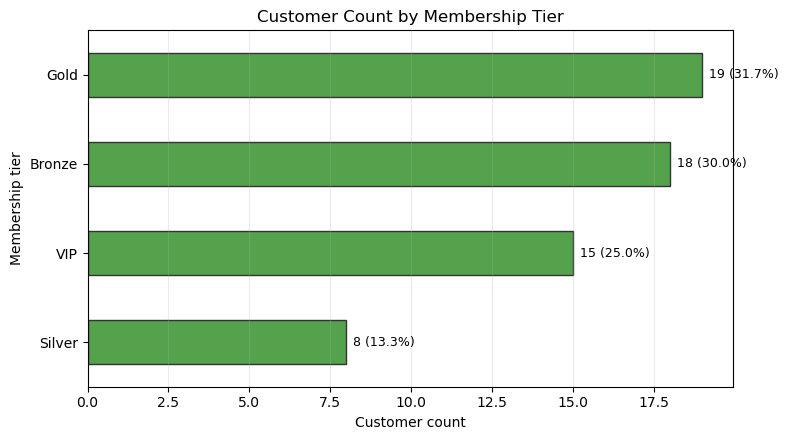

<Axes: title={'center': 'Customer Count by Membership Tier'}, xlabel='Customer count', ylabel='Membership tier'>

In [8]:
membership_counts = analysis_df["membership_tier"].value_counts()
plot_count_chart(
    membership_counts,
    title="Customer Count by Membership Tier",
    xlabel="Customer count",
    ylabel="Membership tier",
    color="#54A24B",
    orientation="horizontal",
)

### 7. Device Distribution

Device usage indicates where the campaign experience should work best. A strong device preference would suggest where landing pages, messages, and purchase flows need the most attention.

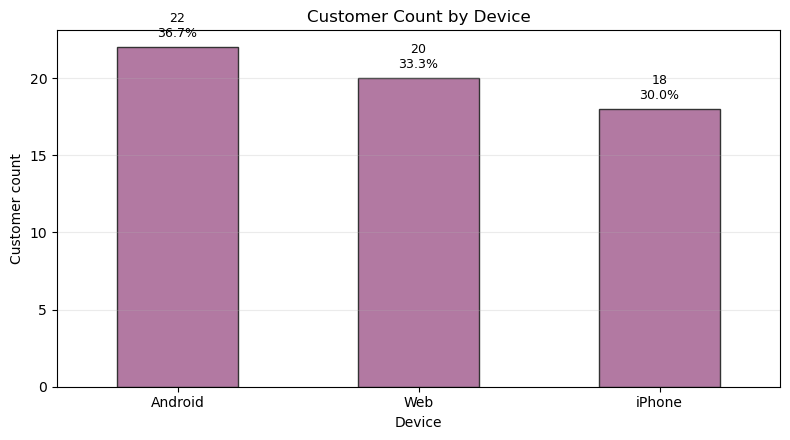

<Axes: title={'center': 'Customer Count by Device'}, xlabel='Device', ylabel='Customer count'>

In [9]:
device_counts = analysis_df["device"].value_counts()
plot_count_chart(
    device_counts,
    title="Customer Count by Device",
    xlabel="Device",
    ylabel="Customer count",
    color="#B279A2",
)

### 8. Payment Method Distribution

Payment method distribution helps identify the checkout behavior of the current customer base. This can guide campaign incentives, payment-specific offers, and checkout messaging.

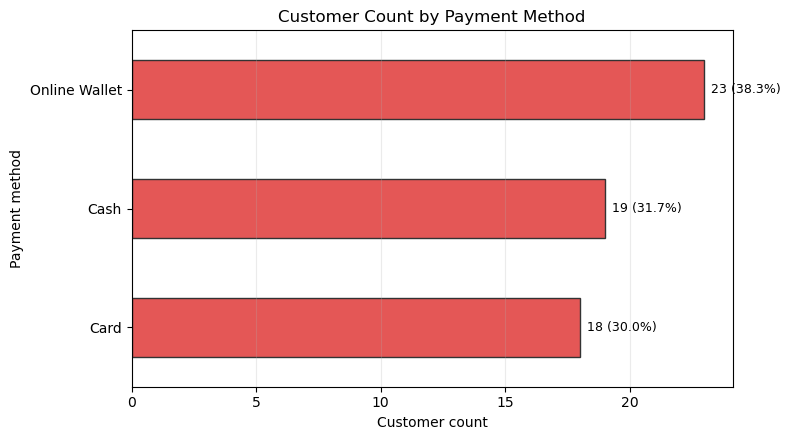

<Axes: title={'center': 'Customer Count by Payment Method'}, xlabel='Customer count', ylabel='Payment method'>

In [10]:
payment_counts = analysis_df["payment_method"].value_counts()
plot_count_chart(
    payment_counts,
    title="Customer Count by Payment Method",
    xlabel="Customer count",
    ylabel="Payment method",
    color="#E45756",
    orientation="horizontal",
)

### 9. Interpretation of the Charts

The charts answer the main exploration questions for this business request:

- The largest age segment is `55-64`, with `45-54` close behind. This means the current customer base leans toward middle-aged and older adult customers rather than very young customers.
- The customer base is majority `Male`, but the difference is not large enough to ignore female customers.
- `Gold` is the most common membership tier, with `Bronze` very close behind. This suggests both loyalty-oriented customers and lower-tier customers are important.
- `Android` is the most common device, followed closely by `Web`, so campaign assets should be checked carefully on both mobile Android and desktop/web flows.
- `Online Wallet` is the most common payment method, making wallet-based checkout messaging or incentives a reasonable first test.

In [11]:
def build_final_answer(summary: pd.Series, df: pd.DataFrame) -> str:
    """Create the final business answer from the computed customer profile summary.

    Args:
        summary: Series returned by summarize_customer_profile().
        df: Prepared customer profile dataset used for the analysis.

    Returns:
        A concise English paragraph answering the business question.
    """
    total = int(summary["customer_count"])
    dominant_age_share = summary["dominant_age_group_count"] / total * 100
    dominant_gender_share = summary["dominant_gender_count"] / total * 100
    dominant_membership_share = summary["dominant_membership_tier_count"] / total * 100
    dominant_device_share = summary["dominant_device_count"] / total * 100
    dominant_payment_share = summary["dominant_payment_method_count"] / total * 100

    return (
        f"The cleaned dataset contains {total} unique customers. The main current customer profile is a "
        f"{summary['dominant_gender']} customer in the {summary['dominant_age_group']} age group, with "
        f"{summary['dominant_membership_tier']} membership, using {summary['dominant_device']}, and most often paying "
        f"with {summary['dominant_payment_method']}. The leading age group has {summary['dominant_age_group_count']} "
        f"customers ({dominant_age_share:.1f}%), and the median customer age is {summary['median_age']:.0f}. "
        f"The leading gender has {summary['dominant_gender_count']} customers ({dominant_gender_share:.1f}%). "
        f"The leading membership tier has {summary['dominant_membership_tier_count']} customers "
        f"({dominant_membership_share:.1f}%), the leading device has {summary['dominant_device_count']} customers "
        f"({dominant_device_share:.1f}%), and the leading payment method has "
        f"{summary['dominant_payment_method_count']} customers ({dominant_payment_share:.1f}%). Because no single "
        f"category fully dominates the dataset, the campaign should prioritize adults aged 45-64, Android and web "
        f"experiences, and online-wallet checkout incentives, while still keeping the message broad enough for other "
        f"segments."
    )


final_answer = build_final_answer(profile_summary, analysis_df)
print(final_answer)

The cleaned dataset contains 60 unique customers. The main current customer profile is a Male customer in the 55-64 age group, with Gold membership, using Android, and most often paying with Online Wallet. The leading age group has 16 customers (26.7%), and the median customer age is 45. The leading gender has 35 customers (58.3%). The leading membership tier has 19 customers (31.7%), the leading device has 22 customers (36.7%), and the leading payment method has 23 customers (38.3%). Because no single category fully dominates the dataset, the campaign should prioritize adults aged 45-64, Android and web experiences, and online-wallet checkout incentives, while still keeping the message broad enough for other segments.


### 10. Final Answer

Based on the cleaned data, the store's main customers are mostly middle-aged and older adult customers, especially the `55-64` and `45-54` age groups. The dominant profile is a `Male` customer, most commonly in the `Gold` membership tier, using `Android`, and paying with `Online Wallet`.

The final campaign decision should not be too narrow because the dataset is fairly balanced across several categories. The strongest first target is customers aged `45-64`, with campaign experiences optimized for `Android` and `Web`, and with payment messaging or incentives around `Online Wallet`. `Gold` customers should be treated as the primary loyalty segment, while `Bronze` customers should also be considered because their count is very close to Gold.